In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

In [34]:
datasets= "./buenos-aires-real-estate-*.csv"

In [35]:
def merged_files(data):
  return(pd.concat
    ([
        pd.read_csv
         (x, engine='python'  # Handles non-standard CSV formatting that causes C-parser errors
          , on_bad_lines='skip' # Drops corrupted rows with extra/missing commas instead of crashing
         ) for x in glob(data)
     ],
     ignore_index= True # Resets index so combined rows are numbered continuously (0 to N-1)
    )
  )

df= merged_files(datasets)
df.head()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,PH,|Argentina|Bs.As. G.B.A. Zona Norte|Tigre|Tigre|,"-34.4281108,-58.5728848",160000.0,USD,2425984.0,160000.0,169.0,77.0,946.745562,2077.922078,NaN,NaN,NaN,http://tigre.properati.com.ar/i4rw_venta_depar...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Norte|Tigre|Bena...,NaN,270000.0,USD,4093848.0,270000.0,790.0,221.0,341.772152,1221.719457,NaN,NaN,NaN,http://benavidez.properati.com.ar/n4go_venta_c...
2,sell,apartment,|Argentina|Capital Federal|Recoleta|,"-34.5889927,-58.4001326",215000.0,USD,3259916.0,215000.0,40.0,35.0,5375.000000,6142.857143,NaN,1.0,3500.0,http://recoleta.properati.com.ar/12j4v_venta_d...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5879654,-58.5862179",NaN,NaN,NaN,NaN,277.0,113.0,NaN,NaN,NaN,4.0,NaN,http://tres-de-febrero.properati.com.ar/um5c_v...
4,sell,apartment,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5995115,-58.5538716",90000.0,USD,1364616.0,90000.0,200.0,90.0,450.000000,1000.000000,NaN,3.0,NaN,http://tres-de-febrero.properati.com.ar/10yhb_...


#Using engine='python' in Pandas

By default, pd.read_csv() relies on Pandas' native C engine (engine='c'), which is optimized for speed but enforces strict CSV formatting rules.

In this dataset, property listings contain messy, scraped text fields with unescaped quotation marks, irregular commas, and unexpected formatting that cause the fast C-parser to crash with a ParserError.

Setting engine='python' switches Pandas to its regex-backed Python parser. While slightly slower, the Python engine is significantly more forgiving with raw, unstructured text and successfully parses complex strings without failing.

###What is parsing?
In computing, parsing simply means taking a raw string of text and translating it into a structured format that a program can understand and manipulate.

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21521 entries, 0 to 21520
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   21521 non-null  object 
 1   property_type               21521 non-null  object 
 2   place_with_parent_names     21521 non-null  object 
 3   lat-lon                     17373 non-null  object 
 4   price                       19008 non-null  float64
 5   currency                    19007 non-null  object 
 6   price_aprox_local_currency  19008 non-null  float64
 7   price_aprox_usd             19008 non-null  float64
 8   surface_total_in_m2         14945 non-null  float64
 9   surface_covered_in_m2       18289 non-null  float64
 10  price_usd_per_m2            12233 non-null  float64
 11  price_per_m2                16392 non-null  float64
 12  floor                       3222 non-null   float64
 13  rooms                       120

In [37]:
df["property_type"].value_counts()

,count
property_type,
apartment,11687
house,7843
PH,1399
store,592


#### Filtering our dataset such that:
* We only work on apartments. Why? Because our data is heterogenous.Houses and commercial spaces follow different pricing mechanics  than apartments (lot size, zoning, business revenue potential)

* We only work with Capital Federal and not GBA because a model trained on both would be mediocre at predicting in either market, because the pricing logic differs.
> Capital Federal: Dense urban core where walkability, transit proximity, building amenities, and neighborhood prestige drive high prices per square meter. The key features are size and location within the city.    
Greater Buenos Aires: Diverse suburban and semi-rural zones where lot size, commute distance, and proximity to commercial centers matter more. A different set of features drives prices.

* Price <400,000$: caps the range to typical residential buyers, excluding luxury outliers whose prices are driven by factors our features do not capture


In [38]:
def filter_data(data):
  return (data.loc[lambda x: x["place_with_parent_names"].str.contains("Capital Federal", na=False)].query('property_type=="apartment"').query('price_aprox_usd< 400000').reset_index(drop=True))

# .loc[] is the primary method used to select or filter rows and columns based on conditions or labels.

# Setting na=False means that any row where place_with_parent_names is missing (NaN) will be treated as False by the filter. Because .loc[] only keeps rows where the condition evaluates to True, those NaN rows are excluded (dropped) from the new filtered DataFrame.

### Handling outliers:
Even within Capital Federal apartments under $400K, the surface area column (surface_covered_in_m2) still contains extreme values that would distort the model's learned coefficients.

Therefore we keep only properties between the 10th and 90th percentile of surface area

Using .quantile(0.1) and .quantile(0.9) rather than hard-coded numbers like 20 and 150 makes the filter adaptive: it adjusts automatically if the data distribution changes

In [39]:
def handle_outliers(data):
   return(data.loc[lambda x: x["surface_covered_in_m2"].between(x["surface_covered_in_m2"].quantile(0.1),
                                                        x["surface_covered_in_m2"].quantile(0.9))])


In [ ]:
df

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.00,180000.00,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
1,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...,NaN,250000.0,USD,3790600.00,250000.00,117.0,120.0,2136.752137,2083.333333,NaN,4.0,NaN,http://ramos-mejia.properati.com.ar/s7pd_venta...
2,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Morón|Cast...,"-34.6497002,-58.658073",410000.0,USD,6216584.00,410000.00,410.0,220.0,1000.000000,1863.636364,NaN,NaN,NaN,http://castelar-moron.properati.com.ar/11vgn_v...
3,sell,house,|Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...,"-34.5957086,-58.5669503",180000.0,USD,2729232.00,180000.00,200.0,135.0,900.000000,1333.333333,NaN,5.0,NaN,http://tres-de-febrero.properati.com.ar/7f7u_v...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.60,129000.00,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43024,sell,apartment,|Argentina|Bs.As. G.B.A. Zona Norte|San Fernan...,"-34.4498923,-58.5333348",191800.0,USD,2908148.32,191800.00,68.0,54.0,2820.588235,3551.851852,1.0,NaN,NaN,http://victoria.properati.com.ar/nj3n_venta_de...
43025,sell,house,|Argentina|Bs.As. G.B.A. Zona Norte|Vicente Ló...,"-34.5356489416,-58.4981208948",550000.0,USD,8339320.00,550000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://florida.properati.com.ar/j5jl_venta_cas...
43026,sell,apartment,|Argentina|Capital Federal|Belgrano|,"-34.5522215,-58.4448022",560000.0,USD,8490944.00,560000.00,137.0,126.0,4087.591241,4444.444444,NaN,3.0,7000.0,http://belgrano.properati.com.ar/12pck_venta_d...
43027,sell,apartment,|Argentina|Bs.As. G.B.A. Zona Norte|General Sa...,"-34.580145797,-58.5542081641",180000.0,ARS,179500.37,11838.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://san-martin.properati.com.ar/edzj_venta_...


In [40]:
def modify_cols(data):
    return (
        data
        .assign(lat= lambda x: x["lat-lon"].str.split(",", expand=True)[0].astype(float),
                lon= lambda x: x["lat-lon"].str.split(",", expand=True)[1].astype(float),
                neighborhood= lambda x: x["place_with_parent_names"].str.split("|", expand=True)[3]
                # Index 3 extracts neighborhood from format: '|Country|Region|Neighborhood|'
        )
    )



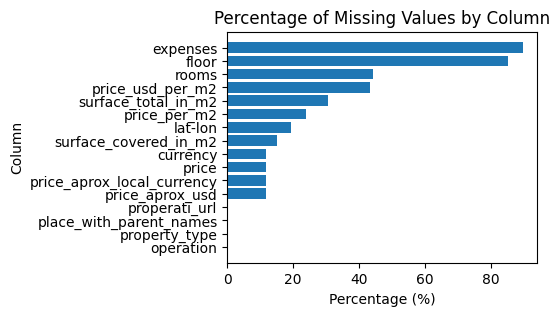

In [41]:
#missing values per column percentage

missing_per_col= (df.isna().sum(axis=0)*100/len(df)).sort_values()

fig, ax= plt.subplots(figsize=(4, 3))

ax.barh(missing_per_col.index, missing_per_col.values)
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Column')
plt.show()


####Key observations:

expenses and floor are missing more than 50% of their values
rooms is missing around 40%

price_aprox_usd — our target — has some missing values but is mostly complete

/usr/local/lib/python3.12/dist-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


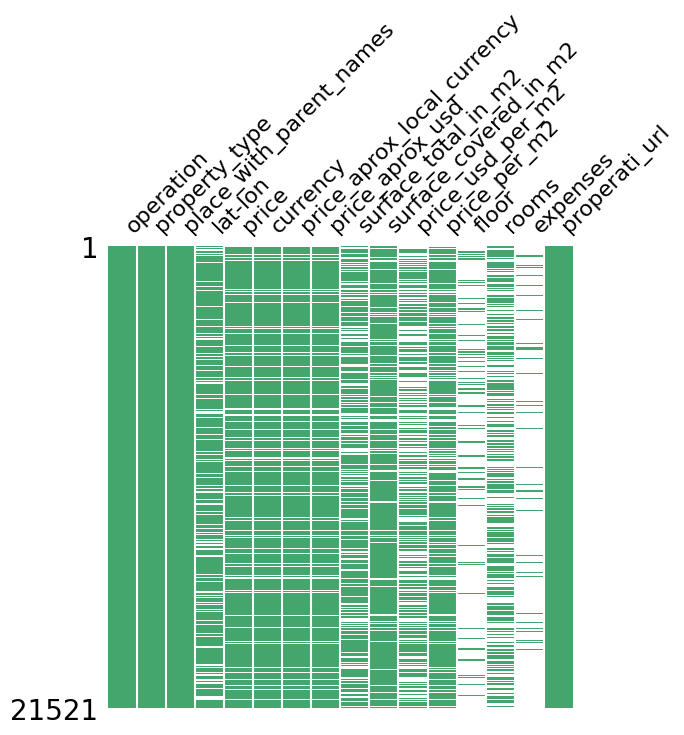

In [42]:
import missingno as msno

# missingno.matrix visualizes whether missing values occur randomly across rows or if columns are missing together(e.g., price and currency missing on the same listings).

fig, ax = plt.subplots(figsize=(6, 6))
msno.matrix(df, color=(0.27, 0.65, 0.43), ax=ax)
plt.show()

###Key Observations:
currency, price_aprox_local_currency, and price_aprox_usd tend to be missing together — these co-occur in rows where no price information was recorded at all

expenses has the most white space, followed by floor and rooms

Decision: Keep price_aprox_usd (our target variable) and drop all other price-related and high-missingness columns. The pattern of co-occurrence with other price columns confirms that rows missing price_aprox_usd are simply unpriced listings — we cannot recover them.

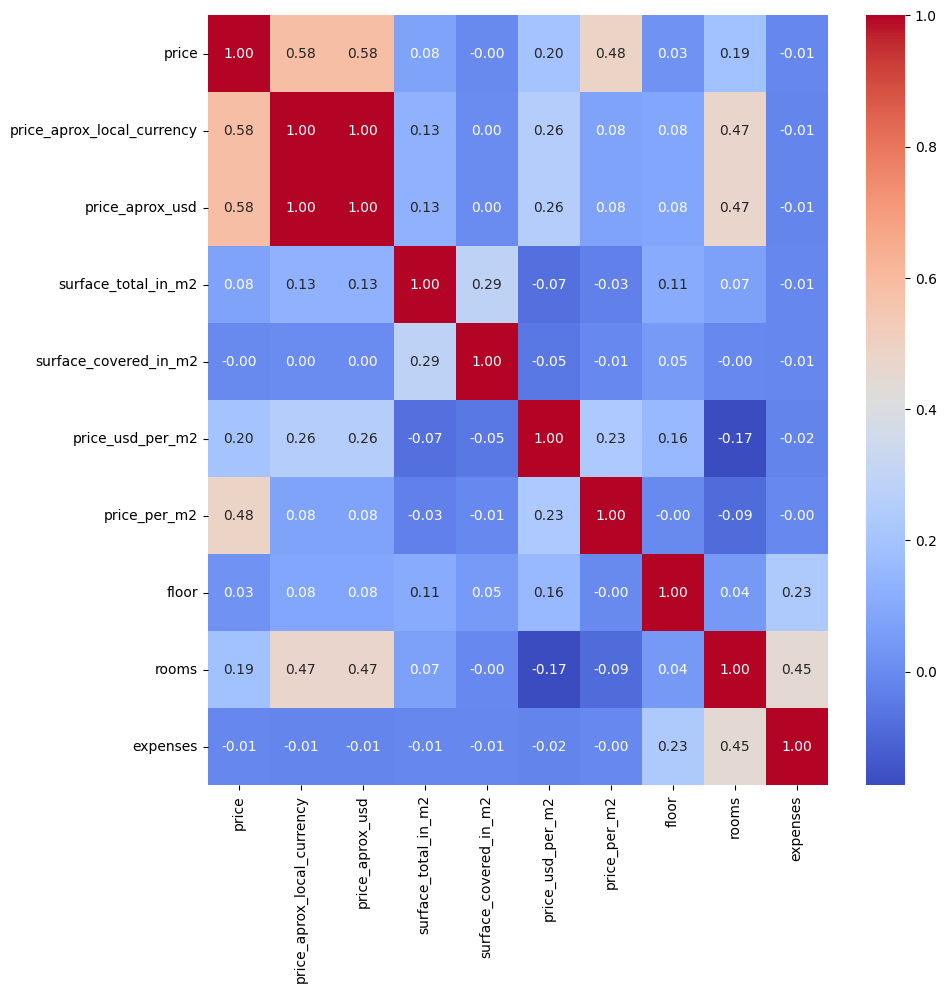

In [43]:
corr_mat= df.corr(numeric_only=True)
fig, ax= plt.subplots(figsize=(10, 10))
sns.heatmap(corr_mat, annot= True, cmap="coolwarm", ax=ax, fmt= '.2f')
plt.show()

## DROPPING UNNECESSARY COLUMNS
* High missingness (>50%): expenses, floor, rooms
* Data leakage:	price, price_aprox_local_currency,    price_usd_per_m2, price_per_m2
* Unique identifiers:	properati_url
* Already extracted: lat-lon, place_with_parent_names
* Single-value columns:	operation, property_type, currency

Note: 'surface_total_in_m2' is dropped due to domain redundancy with 'surface_covered_in_m2'.
 Although raw correlation appears low (0.29) due to uncleaned outliers, both columns
measure apartment size; keeping 'surface_covered_in_m2' alone avoids feature redundancy.

## EDA (exploratory data analysis) Note:

1. Data Leakage: They directly reveal information about our target variable (price_aprox_usd).
 2. Multicollinearity: They show near-perfect correlation (1.00) with each other.

In [44]:
# MASTER FILES
def clean_files(data):
  return(merged_files(data).pipe(filter_data).pipe(handle_outliers).pipe(modify_cols))

clean_df= clean_files(datasets)

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3333 entries, 0 to 4426
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   3333 non-null   object 
 1   property_type               3333 non-null   object 
 2   place_with_parent_names     3333 non-null   object 
 3   lat-lon                     3204 non-null   object 
 4   price                       3333 non-null   float64
 5   currency                    3333 non-null   object 
 6   price_aprox_local_currency  3333 non-null   float64
 7   price_aprox_usd             3333 non-null   float64
 8   surface_total_in_m2         2406 non-null   float64
 9   surface_covered_in_m2       3333 non-null   float64
 10  price_usd_per_m2            2291 non-null   float64
 11  price_per_m2                3333 non-null   float64
 12  floor                       951 non-null    float64
 13  rooms                       2675 non-n

In [66]:
# Columns to remove based on EDA (leakage, high missingness, and feature redundancy)
drop_cols = [
    "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2", "price_per_m2",
    "surface_total_in_m2", "properati_url",
    "operation", "property_type", "currency"
  ]

# Drop columns via reassignment; errors='ignore' prevents crashing if re-run

clean_df = clean_df.drop(columns=drop_cols, errors="ignore")
# Reassignment over inplace=True: The pandas core development team actively discourages inplace=True because it rarely provides memory savings and can trigger SettingWithCopyWarning warnings down the pipeline.

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3333 entries, 0 to 4426
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        3333 non-null   float64
 1   surface_covered_in_m2  3333 non-null   float64
 2   lat                    3204 non-null   float64
 3   lon                    3204 non-null   float64
 4   neighborhood           3333 non-null   object 
dtypes: float64(4), object(1)
memory usage: 156.2+ KB


In [67]:
clean_df= clean_df.dropna()
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3204 entries, 0 to 4426
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        3204 non-null   float64
 1   surface_covered_in_m2  3204 non-null   float64
 2   lat                    3204 non-null   float64
 3   lon                    3204 non-null   float64
 4   neighborhood           3204 non-null   object 
dtypes: float64(4), object(1)
memory usage: 150.2+ KB


In [ ]:
clean_df["neighborhood"].unique()

array(['Chacarita', 'Villa Luro', 'Caballito', 'Constitución', 'Once',
       'Almagro', 'Palermo', 'Flores', 'Belgrano', 'Liniers',
       'Villa Crespo', 'San Cristobal', 'Congreso', 'Saavedra',
       'Balvanera', 'Parque Avellaneda', 'Recoleta', 'San Telmo', 'Nuñez',
       'Barrio Norte', 'Parque Centenario', 'Abasto',
       'Centro / Microcentro', 'Paternal', 'Mataderos', 'Villa Lugano',
       '', 'Coghlan', 'Las Cañitas', 'Villa Urquiza', 'Monserrat',
       'Villa Pueyrredón', 'Parque Patricios', 'San Nicolás',
       'Villa del Parque', 'Boedo', 'Parque Chacabuco', 'Parque Chas',
       'Colegiales', 'Villa General Mitre', 'Villa Ortuzar',
       'Villa Devoto', 'Floresta', 'Barracas', 'Retiro', 'Versalles',
       'Boca', 'Puerto Madero', 'Agronomía', 'Monte Castro', 'Tribunales',
       'Villa Santa Rita', 'Velez Sarsfield', 'Villa Soldati',
       'Villa Real', 'Pompeya'], dtype=object)

In [29]:
# there exists a " " for the neighborhood. dropna() missed it bcs it only considers NaN as a missing value and " " a valid string


# 1. Replace empty strings or whitespace in 'neighborhood' with NaN
# ^: beginning of string | \s: white space, \n, \t | *: zero or more times | $: end of string
clean_df["neighborhood"] = clean_df["neighborhood"].replace(r"^\s*$", np.nan, regex=True)

# 2. Drop NaNs and reset index to ensure clean row alignment
clean_df = clean_df.dropna().reset_index(drop=True)

# Check unique neighborhoods to verify '' is gone
print(clean_df["neighborhood"].unique())

['Recoleta' 'Monserrat' 'Belgrano' 'Villa del Parque' 'Villa Pueyrredón'
 'Almagro' 'Palermo' 'Tribunales' 'Balvanera' 'Barrio Norte' 'Once'
 'San Telmo' 'Villa Lugano' 'Coghlan' 'Barracas' 'Villa Urquiza' 'Abasto'
 'Villa Crespo' 'Villa Santa Rita' 'Colegiales' 'Paternal' 'Caballito'
 'Retiro' 'Villa Devoto' 'Villa Luro' 'San Nicolás' 'Saavedra' 'Flores'
 'Centro / Microcentro' 'Liniers' 'San Cristobal' 'Boca' 'Congreso'
 'Parque Centenario' 'Parque Chas' 'Nuñez' 'Boedo' 'Floresta'
 'Parque Chacabuco' 'Puerto Madero' 'Parque Patricios'
 'Villa General Mitre' 'Villa Ortuzar' 'Chacarita' 'Mataderos'
 'Velez Sarsfield' 'Monte Castro' 'Las Cañitas' 'Agronomía'
 'Parque Avellaneda' 'Constitución' 'Versalles' 'Pompeya' 'Villa Soldati'
 'Villa Real']


In [68]:
target = "price_aprox_usd"

X = clean_df.drop(columns=[target])
y = clean_df[target]

# 2. Split into training and test sets BEFORE preprocessing/pipelines
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (2563, 4)
X_test shape:  (641, 4)


In [62]:
!pip install category_encoders

#**1. Diagnostic Exploration of Regularization Penalties**

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from category_encoders import OneHotEncoder

In [70]:
mean_train_price= round(y_train.mean(), 2)
print(mean_train_price)

132844.77


In [71]:
model_ridge= make_pipeline(OneHotEncoder(use_cat_names= True), StandardScaler(), Ridge(alpha= 1.0))
model_ridge.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighborhood'], use_cat_names=True)),
                ('standardscaler', StandardScaler()), ('ridge', Ridge())])

In [72]:
#predict on training data
y_pred_ridge_train= model_ridge.predict(X_train)
rmse_ridge_train= root_mean_squared_error(y_train, y_pred_ridge_train)

#predict on test data
y_pred_ridge_test= model_ridge.predict(X_test)
rmse_ridge_test= root_mean_squared_error(y_test, y_pred_ridge_test)

print(f"RMSE_RIDGE_TRAIN: ${rmse_ridge_train:,.2f}")
print(f"RMSE_RIDGE_TEST: ${rmse_ridge_test:,.2f}")

RMSE_RIDGE_TRAIN: $32,983.76
RMSE_RIDGE_TEST: $35,562.77


Key Takeaway — Ridge Baseline Evaluation:Train RMSE: ~$32,983.76Test RMSE: $35,562.77Generalization Check: The gap between train and test RMSE is relatively small ($2,579), indicating that regularizing with alpha=1.0 prevents variance explosion without causing severe underfitting.

In [73]:
model_lasso= make_pipeline(OneHotEncoder(use_cat_names= True), StandardScaler(), Lasso(alpha= 100, max_iter=10000))
model_lasso.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighborhood'], use_cat_names=True)),
                ('standardscaler', StandardScaler()),
                ('lasso', Lasso(alpha=100, max_iter=10000))])

In [74]:
#predict on training data
y_pred_lasso_train= model_lasso.predict(X_train)
rmse_lasso_train= root_mean_squared_error(y_train, y_pred_lasso_train)

#predict on test data
y_pred_lasso_test= model_lasso.predict(X_test)
rmse_lasso_test= root_mean_squared_error(y_test, y_pred_lasso_test)

print(f"RMSE_LASSO_TRAIN: ${rmse_lasso_train:,.2f}")
print(f"RMSE_LASSO_TEST: ${rmse_lasso_test:,.2f}")

RMSE_LASSO_TRAIN: $33,010.35
RMSE_LASSO_TEST: $35,564.49


Key Takeaway — Lasso Baseline Evaluation:Train RMSE: ~$33,010.35Test RMSE: 35,564.49 Generalization Check: Just like Ridge, Lasso maintains a very low train-test gap (2,554). The L_1 penalty successfully controls variance and prevents overfitting, performing almost identically to Ridge at this initial baseline penalty.

# **Test a wide range of alphas across 3 orders of magnitude**

In [76]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for a in alphas:
    model = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        StandardScaler(),
        Ridge(alpha=a)
    )
    model.fit(X_train, y_train) # <-- fit on train

    # Calculate RMSE for training and test
    rmse_train = root_mean_squared_error(y_train, model.predict(X_train))  # <-- y_train_3 & X_train_3
    rmse_test = root_mean_squared_error(y_test, model.predict(X_test))   # <-- y_test_3 & X_test_3

    ridge_results.append({
        "alpha": a,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test
    })

df_ridge_results = pd.DataFrame(ridge_results)
print(df_ridge_results)

      alpha    rmse_train     rmse_test
0     0.001  32983.747949  35564.500985
1     0.010  32983.747950  35564.485100
2     0.100  32983.748073  35564.326534
3     1.000  32983.760243  35562.768253
4    10.000  32984.881143  35549.689705
5   100.000  33051.648286  35551.651135
6  1000.000  35327.904926  37755.680118


### Hyperparameter Exploration: Testing Across Orders of Magnitude

An **order of magnitude** refers to a factor of 10 ($10^1$). Testing $\alpha$ across 3 orders of magnitude relative to $1$ means evaluating hyperparameter values across a logarithmic scale spanning from $10^{-3}$ to $10^3$:

* **3 orders of magnitude smaller ($10^{-3}$):** $1 \xrightarrow{\div 10} 0.1 \xrightarrow{\div 10} 0.01 \xrightarrow{\div 10} \mathbf{0.001}$
* **3 orders of magnitude larger ($10^3$):** $1 \xrightarrow{\times 10} 10 \xrightarrow{\times 10} 100 \xrightarrow{\times 10} \mathbf{1000}$

#### Why Logarithmic Search?
Regularization penalties affect loss functions exponentially rather than linearly. Small linear steps (e.g., $\alpha = 1, 2, 3$) yield negligible performance differences. Scanning across powers of 10 ($0.001$ to $1000$) allows us to efficiently locate the broad optimal region before fine-tuning.

#### Key Observations from Results:
* **Sweet Spot ($\alpha = 10$ to $100$):** Test RMSE reaches its minimum ($\sim \$35,549.69$) around $\alpha = 10$.
* **Underfitting ($\alpha = 1000$):** Test RMSE jumps to $\sim \$37,755.68$, showing that a penalty of $1000$ over-constrains feature coefficients and hurts generalization.

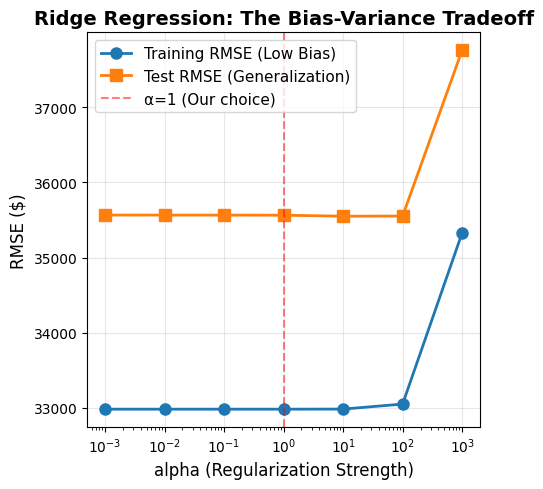

In [77]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(df_ridge_results["alpha"], df_ridge_results["rmse_train"],
        marker='o', linewidth=2, markersize=8, label="Training RMSE (Low Bias)")

ax.plot(df_ridge_results["alpha"], df_ridge_results["rmse_test"],
        marker='s', linewidth=2, markersize=8, label="Test RMSE (Generalization)")

ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label="α=1 (Our choice)")

ax.set_xlabel("alpha (Regularization Strength)", fontsize=12)
ax.set_ylabel("RMSE ($)", fontsize=12)
ax.set_xscale("log")
ax.set_title("Ridge Regression: The Bias-Variance Tradeoff", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 📈 Visual Diagnosis: The Bias-Variance Tradeoff in Ridge Regression

This plot illustrates how varying the $L_2$ regularization penalty ($\alpha$) across 6 orders of magnitude affects model performance:

1. **Optimal Generalization ($\alpha = 10^{-3}$ to $10^2$):**
   * Between $\alpha = 0.001$ and $\alpha = 100$, both Training RMSE ($\sim\$33,000$) and Test RMSE ($\sim\$35,550$) remain low and stable.
   * Selecting $\alpha = 1.0$ effectively keeps the variance under control without sacrificing accuracy.

2. **Underfitting Zone ($\alpha \ge 10^3$):**
   * As $\alpha$ increases to $1000$, the $L_2$ penalty becomes excessively strict, overly shrinking model coefficients.
   * This causes both Training RMSE ($\sim\$35,328$) and Test RMSE ($\sim\$37,756$) to spike dramatically, indicating that the model has begun to **underfit**.

In [79]:
lasso_results= []
alphas= [0.1, 1, 10, 100, 1000]

for a in alphas:
  model= make_pipeline(OneHotEncoder(use_cat_names= True), StandardScaler(), Lasso(alpha= a, max_iter= 100000))
  ## Increased max_iter to ensure convergence: convergence means the mathematical algorithm has successfully found the optimal solution (the absolute lowest point of prediction error) and stopped changing.

  model.fit(X_train, y_train)

  rmse_train= root_mean_squared_error(y_train, model.predict(X_train))
  rmse_test= root_mean_squared_error(y_test, model.predict(X_test))
  non_zero_features = (model.named_steps["lasso"].coef_ != 0).sum()


  lasso_results.append({
      "alpha": a,
      "rmse_train": rmse_train,
      "rmse_test": rmse_test,
      "non zero features": non_zero_features
  })

lasso_res_df= pd.DataFrame(lasso_results)
lasso_res_df

,alpha,rmse_train,rmse_test,non zero features
0,0.1,32983.747987,35564.474172,58
1,1.0,32983.751760,35564.220072,58
2,10.0,32984.103152,35561.824930,58
3,100.0,33010.350550,35564.487216,57
4,1000.0,33628.962956,36122.818298,26


### 🎯 Lasso Regularization & Feature Selection Analysis

Unlike Ridge, **Lasso ($L_1$ regularization)** performs feature selection by driving irrelevant feature coefficients to **exact zero**.

#### Key Observations:
* **Optimal Performance ($\alpha = 10$):** Test RMSE hits its global minimum at **$\$35,561.82$** while keeping all 58 features active.
* **Automatic Feature Elimination ($\alpha = 100 \rightarrow 1000$):**
  * At $\alpha = 100$, 1 feature is zeroed out (57 remaining) with virtually no loss in accuracy ($\sim \$35,564$).
  * At $\alpha = 1000$, Lasso heavily penalizes coefficients, zeroing out **32 features** (leaving only 26).
* **Tradeoff Analysis:** While $\alpha = 1000$ increases Test RMSE slightly ($\sim \$36,122$), it reduces model complexity by **over $55\%$**, offering a much simpler, highly interpretable model for a minor loss in predictive precision.

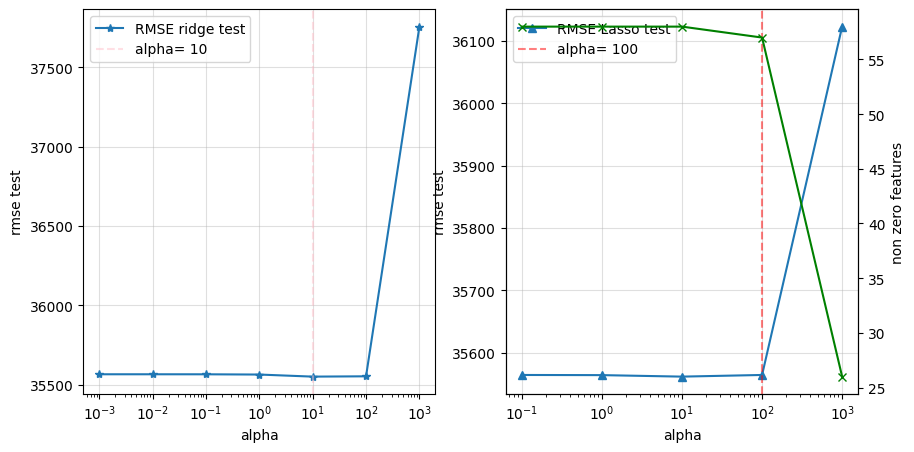

In [88]:
fig, (ax1, ax2)= plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(df_ridge_results["alpha"], df_ridge_results["rmse_test"], marker="*", label="RMSE ridge test")
ax1.axvline(x=10, alpha=0.5, linestyle="--", label= "alpha= 10 ", color= "pink")
ax1.set_xscale("log")
ax1.set_xlabel("alpha")
ax1.set_ylabel("rmse test")
ax1.legend()
ax1.grid(True, alpha= 0.4)


ax2_twin= ax2.twinx()
ax2.plot(lasso_res_df["alpha"], lasso_res_df["rmse_test"], marker= "^", label= "RMSE Lasso test")
ax2_twin.plot(lasso_res_df["alpha"], lasso_res_df["non zero features"], marker="x", color= "green", label="non zero features")
ax2.set_xscale("log")
ax2.axvline(x=100, alpha=0.5, color= "red", label= "alpha= 100", linestyle="--")
ax2.set_xlabel("alpha")
ax2.set_ylabel("rmse test")
ax2_twin.set_ylabel("non zero features")
ax2.legend()
ax2.grid(True, alpha=0.4)


### 📊 Comparative Analysis: Ridge vs. Lasso Regularization

#### 1. Ridge Regression (Left):
* **Stability:** Across $\alpha \in [0.001, 100]$, the Test RMSE remains nearly identical ($\sim \$35,562$), showing strong stability.
* **Underfitting Threshold:** Once $\alpha$ exceeds $100$ and approaches $1000$, the $L_2$ penalty becomes too aggressive, forcing Test RMSE up to $\sim \$37,755$.
* **Optimal Range:** Any $\alpha \le 10$ provides optimal regularization without incurring high bias.

#### 2. Lasso Regression & Sparsity (Right):
* **Feature Elimination:**
  * At $\alpha = 10$, Lasso retains all 58 features with optimal Test RMSE ($\sim \$35,561.82$).
  * At $\alpha = 100$, Lasso drops 1 feature (57 non-zero features remaining) with no loss in accuracy.
  * At $\alpha = 1000$, Lasso aggressively eliminates 32 features—reducing model complexity by over $55\%$ (down to 26 features) for only a minor increase in RMSE ($\sim \$36,122$).
* **Practical Takeaway:** If maximum predictive accuracy is required, **$\alpha = 10$** is ideal. If model simplicity and feature reduction are preferred, **$\alpha = 100$** offers a significantly sparser model with essentially the same accuracy.

##**Automated Hyperparameter Optimization via Cross-Validation**

In [85]:
from sklearn.linear_model import RidgeCV, LassoCV

ridgecv_mod= make_pipeline(OneHotEncoder(use_cat_names= True), StandardScaler(), RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10, 100, 1000], cv=5))

ridgecv_mod.fit(X_train, y_train)

optimal_ridge_alpha= ridgecv_mod.named_steps["ridgecv"].alpha_
rmse= root_mean_squared_error(y_test, ridgecv_mod.predict(X_test))

print(optimal_ridge_alpha)
print(rmse)


10.0
35549.68970489855


In [87]:
lassocv_mod= make_pipeline(OneHotEncoder(use_cat_names= True), StandardScaler(), LassoCV(alphas=[0.001, 0.01, 0.1, 1.0, 10, 100, 1000], cv=5, max_iter=100000,  random_state=42))

lassocv_mod.fit(X_train, y_train)

optimal_lasso_alpha= lassocv_mod.named_steps["lassocv"].alpha_
rmse_lasso= root_mean_squared_error(y_test, lassocv_mod.predict(X_test))

print(optimal_lasso_alpha)
print(rmse_lasso)


100.0
35564.4872157742


In [89]:
coeff= lassocv_mod.named_steps["lassocv"].coef_
feat= lassocv_mod.named_steps["onehotencoder"].get_feature_names_out()
imp_feat= pd.Series(coeff, index=  feat)

print("total length", len(imp_feat))
print("no. of non zero features", (coeff != 0).sum())

total length 59
no. of non zero features 57


### 🏆 Model Selection: Why Lasso Over Ridge?

While both cross-validated models achieved virtually identical predictive accuracy (**Test RMSE $\approx \$35.5\text{k}$**), **LassoCV was selected as the optimal model** for two key reasons:

1. **Automatic Feature Elimination ($L_1$ Penalty):** LassoCV set redundant/noisy feature coefficients to exact zero, pruning the feature space down from **59 to 57 active features** (dropping 2 features). In contrast, RidgeCV retained all 59 features.
2. **Enhanced Model Interpretability:** Eliminating zero-impact predictors creates a simpler, cleaner model that is easier to explain to business stakeholders and maintain in production—without sacrificing any predictive power.

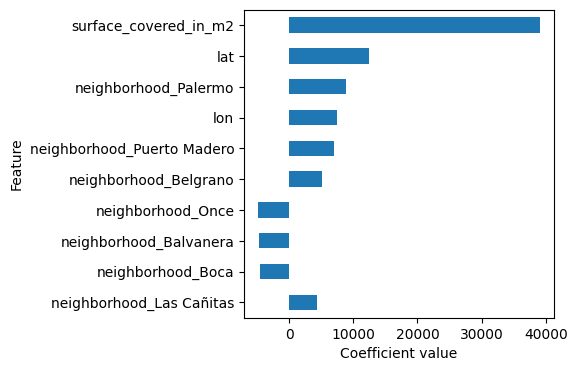

In [90]:
fig, ax= plt.subplots(figsize=(4, 4))
imp_feat.sort_values(key=abs).tail(10).plot(kind="barh", ax=ax)

ax.set_xlabel("Coefficient value")
ax.set_ylabel("Feature")
plt.show()

### 📊 Interpretation of Feature Importance (LassoCV)

Since features were standardized prior to modeling, the coefficient magnitudes directly represent feature importance (impact on property price per 1-standard-deviation change):

#### 1. Primary Driver: Property Size
* **`surface_covered_in_m2` ($\approx +\$39,000$):** Physical size is by far the single strongest predictor of property value—dramatically outperforming all other variables.

#### 2. Spatial & Location Trends
* **Coordinates (`lat`, `lon`):** Both latitude ($\approx +\$12,500$) and longitude ($\approx +\$7,500$) carry strong positive coefficients, capturing overarching spatial price gradients across the region.

#### 3. Neighborhood Price Premiums (Positive Impact)
* High-end neighborhoods—specifically **`Palermo`**, **`Puerto Madero`**, **`Belgrano`**, and **`Las Cañitas`**—add significant positive price premiums to a property's valuation.

#### 4. Neighborhood Price Discounts (Negative Impact)
* Neighborhoods such as **`Once`**, **`Balvanera`**, and **`Boca`** have negative coefficients ($\sim -\$4,500$ to $-\$5,000$), indicating that location in these areas decreases the predicted property value relative to the baseline.

#**2. Automated Cross-Validation & Benchmark Comparison**

Now that we visually understand how Ridge and Lasso behave across different alpha values, we will use 5-fold Cross Validation (RidgeCV and LassoCV) to automatically select the optimal hyperparameters and benchmark all 4 models.

In [91]:
print(len(X_train))
print(len(X_test))

2563
641


In [92]:
def get_rmse(model, X, y_true):
  y_pred= model.predict(X)
  rmse= root_mean_squared_error(y_true, y_pred)
  return rmse

### *1. BASELINE MODEL*

In [95]:
y_mean= y_train.mean()

y_pred_bsl_train= [y_mean]*len(y_train)
y_pred_bsl_test= [y_mean]*len(y_test)

rmse_bsl_train= root_mean_squared_error(y_train, y_pred_bsl_train)
rmse_bsl_test= root_mean_squared_error(y_test, y_pred_bsl_test)

print(f"Baseline Train RMSE: ${rmse_bsl_train: .2f}")
print(f"Baseline Test RMSE: ${rmse_bsl_test: .2f}")


Baseline Train RMSE: $ 57868.72
Baseline Test RMSE: $ 59227.73


### 📉 1. Baseline Model Analysis

* **What it does:** The baseline model serves as our absolute minimum benchmark (the "dumb model"). It completely ignores all features and predicts the exact **mean property price** (`y_train.mean()`) for every single house.
* **Baseline Results:**
  * **Train RMSE:** $\$57,868.72$
  * **Test RMSE:** $\$59,227.73$
* **Why it matters:** Any machine learning model we build (Linear Regression, Ridge, Lasso) **must** achieve an RMSE significantly lower than $\sim \$59.2\text{k}$ on the test set. If our models can't beat this naive baseline, it means our features have no predictive power!

* * * * * * *

### *2. LINEAR REGRESSION MODEL*
The unregularized OLS model serves as a reference point: how well can we do when we use all available features but apply no regularization penalty?

In [96]:
from sklearn.linear_model import LinearRegression

model_linear= make_pipeline(OneHotEncoder(use_cat_names=True), StandardScaler(), LinearRegression())
model_linear.fit(X_train, y_train)

rmse_linear_train= get_rmse(model_linear, X_train, y_train)
# model predicts using y_pred= X_train, then gets rmse of y_train(original) vs y_pred to see how off is the prediction on training data
rmse_linear_test= get_rmse(model_linear, X_test, y_test)

print(f"LinearRegression Train RMSE: ${rmse_linear_train: .2f}")
print(f"LinearRegression Test RMSE: ${rmse_linear_test: .2f}")

LinearRegression Train RMSE: $ 32983.75
LinearRegression Test RMSE: $ 35564.50


### 📈 2. Standard Linear Regression (OLS Benchmark)

* **Performance Metrics:**
  * **Train RMSE:** $\$32,983.75$
  * **Test RMSE:** $\$35,564.50$
* **Comparison vs. Baseline:**
  * Linear regression reduces prediction error by **$\sim \$23,663$ per house**—a **$40\%$ improvement** over the naive baseline ($\$59,227.73$).
* **Overfitting / Variance Check:**
  * The small gap ($\sim \$2,580$) between Train and Test RMSE indicates that the model generalizes well and is not heavily overfitting to the training data.
  * This unregularized Ordinary Least Squares (OLS) model serves as our primary non-regularized benchmark to compare against `RidgeCV` and `LassoCV`.

* * * * * * *

### *3. RIDGE REGRESSION (RidgeCV) MODEL*
Ridge applies the L2 penalty. All features are retained but their coefficients are shrunk. RidgeCV selects
 automatically via 5-fold cross-validation.


In [97]:
model_ridgecv=  make_pipeline(OneHotEncoder(use_cat_names=True), StandardScaler(), RidgeCV(alphas= np.logspace(-2, 4, 100))) #generated 100 values bw 0.01 to 10000 equally spaced in terms of logarithm
model_ridgecv.fit(X_train, y_train)

rmse_ridgecv_train= get_rmse(model_ridgecv, X_train, y_train)
rmse_ridgecv_test= get_rmse(model_ridgecv, X_test, y_test)

alpha_ridge_optimal= model_ridgecv.named_steps["ridgecv"].alpha_

print(f"Alpha chosen by the model is: {alpha_ridge_optimal}")
print(f"RidgeCV Train RMSE: ${rmse_ridgecv_train: .2f}")
print(f"RidgeCV Test RMSE: ${rmse_ridgecv_test: .2f}")

Alpha chosen by the model is: 32.74549162877728
RidgeCV Train RMSE: $ 32993.97
RidgeCV Test RMSE: $ 35532.23


### 🛡️ 3. Ridge Regression with Cross-Validation (RidgeCV)

* **Hyperparameter Search:** Searched across 100 logarithmically spaced $\alpha$ values ranging from $0.01$ to $10,000$.
* **Optimal Regularization Strength:** $\alpha \approx 32.75$
* **Performance Metrics:**
  * **Train RMSE:** $\$32,993.97$
  * **Test RMSE:** $\$35,532.23$
* **Comparison vs. Standard OLS:**
  * RidgeCV reduced Test RMSE from $\$35,564.50$ down to **$\$35,532.23$** (a modest error reduction of $\sim \$32.27$).
  * The $L_2$ penalty slightly shrunken feature coefficients, reducing model variance and narrowing the generalization gap between train and test performance.

* * * * * * *

### *4. LASSO REGRESSION (LassoCV) MODEL*
Lasso applies the L1 penalty. Some coefficients are driven exactly to zero — automatic feature selection. LassoCV selects alpha
 automatically.

In [98]:
model_lassocv=  make_pipeline(OneHotEncoder(use_cat_names=True), StandardScaler(), LassoCV(alphas= np.logspace(-2, 4, 100), max_iter=10000)) #generated 100 values bw 0.01 to 10000 equally spaced in terms of logarithm
model_lassocv.fit(X_train, y_train)

rmse_lassocv_train= get_rmse(model_lassocv, X_train, y_train)
rmse_lassocv_test= get_rmse(model_lassocv, X_test, y_test)

alpha_lasso_optimal= model_lassocv.named_steps["lassocv"].alpha_

print(f"Alpha chosen by the model is: {alpha_lasso_optimal}")
print(f"LassoCV Train RMSE: ${rmse_lassocv_train: .2f}")
print(f"LassoCV Test RMSE: ${rmse_lassocv_test: .2f}")


coefficients = model_lassocv.named_steps["lassocv"].coef_

num_zero = np.sum(coefficients == 0)
num_nonzero = np.sum(coefficients != 0)

print("Total features:", len(coefficients))
print("Non-zero coefficients:", num_nonzero)
print("Zero coefficients:", num_zero)

Alpha chosen by the model is: 100.0
LassoCV Train RMSE: $ 33010.35
LassoCV Test RMSE: $ 35564.49
Total features: 59
Non-zero coefficients: 57
Zero coefficients: 2


### 🎯 Lasso Regression with Cross-Validation (LassoCV)

* **Hyperparameter Search:** Evaluated 100 logarithmically spaced $\alpha$ values ranging from $0.01$ to $10,000$.
* **Optimal Regularization Strength:** $\alpha = 100.0$
* **Performance Metrics:**
  * **Train RMSE:** $\$33,010.35$
  * **Test RMSE:** $\$35,564.49$
* **Feature Selection ($L_1$ Penalty):**
  * **Total Features:** 59
  * **Retained Features (Non-zero):** 57
  * **Eliminated Features (Set to 0):** 2

* * * * *

In [99]:
data= {"Model": ["Baseline", "Linear Regression", "Ridge (CV-tuned)", "Lasso (CV-tuned)"], "Train RMSE": [rmse_bsl_train, rmse_linear_train, rmse_ridgecv_train, rmse_lassocv_train], "Test RMSE": [rmse_bsl_test, rmse_linear_test, rmse_ridgecv_test, rmse_lassocv_test]}

df_results= pd.DataFrame(data)
df_results["Gap"]= df_results["Test RMSE"] - df_results["Train RMSE"]

df_results= df_results.set_index("Model")
df_results


,Train RMSE,Test RMSE,Gap
Model,,,
Baseline,57868.716242,59227.725472,1359.009230
Linear Regression,32983.747949,35564.502750,2580.754801
Ridge (CV-tuned),32993.965684,35532.231471,2538.265786
Lasso (CV-tuned),33010.350550,35564.487216,2554.136666


### 📊 Model Performance & Generalization Comparison

This summary table evaluates model accuracy and overfitting across all four approaches by calculating the **Generalization Gap** ($\text{Test RMSE} - \text{Train RMSE}$):

#### Key Insights:
* **Massive Improvement over Baseline:** All machine learning models reduce prediction error by **$\sim \$23,663$** ($\approx 40\%$) compared to the naive mean baseline ($\$59,227.73$).
* **Top Predictive Performance:** **Ridge (CV-tuned)** achieves the lowest Test RMSE at **$\$35,532.23$** and the smallest generalization gap among the trained models (**$\$2,538.27$**).
* **Parsimony & Efficiency:** **Lasso (CV-tuned)** matches unregularized Linear Regression test accuracy ($\$35,564.49$) while benefiting from feature selection by zeroing out redundant predictors.
* **Low Overfitting Risk:** The tight generalization gap across all linear models ($\approx \$2,500$) confirms strong model stability with low variance on unseen data.

* * * * *

### Final Model Selection & Justification

> **Decision:** **Lasso Regression** is selected as the final production model.

* **Negligible Performance Gap:** Although Ridge Regression achieved the lowest raw error (**Test RMSE: $\$35,532.23$**), its performance edge over Lasso (**Test RMSE: $\$35,564.49$**) was negligible at approximately **$0.09\%$** ($\sim \$32.26$).
* **Feature Parsimony & Interpretability:** Lasso successfully pruned the feature space from **59 down to 57** by setting **2 redundant features** to exact zero, creating a cleaner, more interpretable model with zero practical impact on predictive accuracy.

# 5. Model Evaluation: Actual vs. Predicted Prices

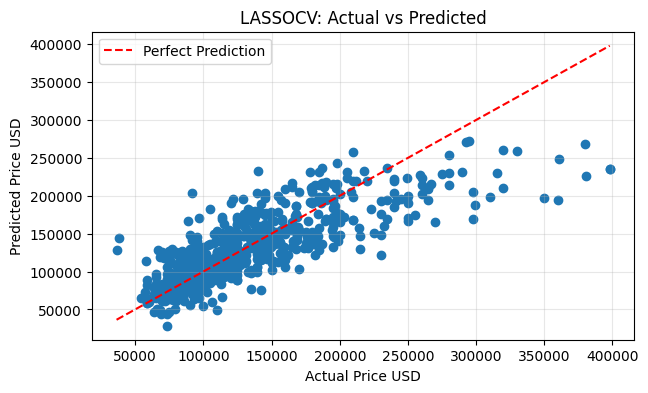

In [104]:
y_pred_lassocv= model_lassocv.predict(X_test)

fig, ax= plt.subplots(figsize= (7, 4))
ax.scatter(y_test, y_pred_lassocv)

ideal_line= np.linspace(y_test.min(), y_test.max(), 100)
ax.plot(ideal_line, ideal_line, linestyle= "--", color="red", label="Perfect Prediction")

ax.set_xlabel("Actual Price USD")

ax.set_ylabel("Predicted Price USD")
ax.set_title("LASSOCV: Actual vs Predicted")
ax.legend()
ax.grid(True, alpha=0.3)

### 📈 Actual vs. Predicted Prices Evaluation (LassoCV)

* **Strong Mid-Range Performance:** The predictions align tightly along the red $45^\circ$ "Perfect Prediction" dashed line for properties valued between **$\$50,000$ and $\$200,000$**, indicating consistent model reliability for mainstream properties.
* **Underprediction at Higher Valuations:** For luxury properties exceeding **$\$250,000$**, the model systematically underpredicts actual prices (points sit noticeably below the diagonal red line). This suggests linear models struggle to capture non-linear premium features in high-end real estate.

* * *

## 📊 Residual Analysis

Residual plots reveal systemic patterns that aggregate error metrics (like RMSE) often hide. A model can achieve a strong overall RMSE while still making systematic errors—such as consistently underestimating expensive apartments while overestimating lower-priced ones. Residual analysis exposes these underlying bias patterns.

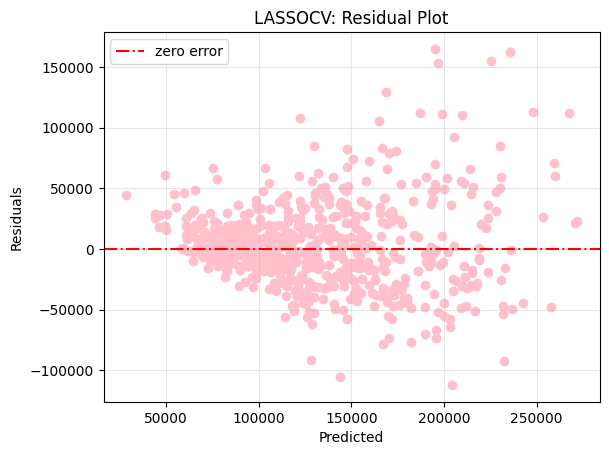

In [105]:
residual= y_test- y_pred_lassocv

fig, ax= plt.subplots()
ax.scatter(y_pred_lassocv, residual, color= "pink")
ax.axhline(y=0, label="zero error", linestyle="-.", color="red")
ax.legend()
ax.set_xlabel("Predicted")
ax.set_ylabel("Residuals")
ax.set_title("LASSOCV: Residual Plot")
ax.legend()
ax.grid(True, alpha=0.3)

### 🧭 How to Read the Residual Plot

* **Horizontal Axis ($X$-Axis) — Predicted Price:** The property value estimated by the AI model ($\hat{y}$).
* **Vertical Axis ($Y$-Axis) — Residual Value:** The prediction error, calculated as:
  $$\text{Residual} = y_{\text{actual}} - \hat{y}_{\text{predicted}}$$

#### 📍 Key Visual Reference Points

* **Red Line ($y = 0$):** **Zero-Error Baseline.** Points sitting directly on this line represent exact predictions where $\text{Actual} = \text{Predicted}$.
* **Dots Above the Line ($> 0$):** **Underpredictions.** The property sold for *more* than expected ($\text{Actual} > \text{Predicted}$).
* **Dots Below the Line ($< 0$):** **Overpredictions.** The property sold for *less* than expected ($\text{Actual} < \text{Predicted}$).

### 📝 Residual Plot Diagnostics & Insights

* **Overall Unbiased Baseline:** The residuals are evenly distributed around the red zero-error line ($y = 0$) for standard properties ($\le \$150,000$), showing that the model does not suffer from consistent global over- or under-estimation.
* **Presence of Heteroscedasticity:** A clear "funnel pattern" emerges as predicted prices increase—the variance of residuals expands significantly at higher property values. Error magnitude is substantially larger for expensive homes.
* **Underprediction of Luxury Homes:** For predicted values above $\$150,000$, several prominent positive residuals exceed $+\$100,000$ to $+\$150,000$. This confirms that linear models struggle to capture non-linear pricing dynamics inherent to high-end real estate.

### ⚠️ Diagnosing Heteroscedasticity

* **Funnel Pattern Detected:** The residual plot displays a distinct funnel-shaped spread, where residual variance expands as predicted property values increase. This confirms **heteroscedasticity** (non-constant error variance across price ranges).

#### 💡 Practical Implications
* **Variable Reliability:** Predictions for mid-range properties are significantly more reliable and tight, whereas high-priced homes exhibit much larger variance.
* **Unobserved Feature Gap:** Luxury properties often possess unique features (custom architecture, premium finishes, unique lot characteristics) that standard linear features cannot fully capture.
* **RMSE Underestimation:** Aggregate metrics like overall RMSE average out errors across all price tiers, effectively understating prediction error for high-end real estate.

> **Key Takeaway:** The model is highly accurate and dependable for typical, mid-tier properties, but predictions for luxury homes carry higher uncertainty and should be evaluated with wider confidence intervals.

* * *

##Feature Importance & Coefficient Interpretation

In [106]:
features= model_lassocv.named_steps["onehotencoder"].get_feature_names_out()

imp_feat= pd.Series(coefficients, index= features)

num_zero = np.sum(coefficients == 0)
num_nonzero = np.sum(coefficients != 0)

print("Total features:", len(coefficients))
print("Non-zero coefficients:", num_nonzero)
print("Zero coefficients:", num_zero)

print("\nTop 5 positive coefficients:")
print(imp_feat.nlargest(5))
print("\nTop 5 negative coefficients:")
print(imp_feat.nsmallest(5))


Total features: 59
Non-zero coefficients: 57
Zero coefficients: 2

Top 5 positive coefficients:
surface_covered_in_m2         39101.850274
lat                           12485.883425
neighborhood_Palermo           8943.185044
lon                            7456.462291
neighborhood_Puerto Madero     7068.126427
dtype: float64

Top 5 negative coefficients:
neighborhood_Once           -4824.650722
neighborhood_Balvanera      -4759.875107
neighborhood_Boca           -4534.321914
neighborhood_Congreso       -3930.544956
neighborhood_Constitución   -2492.881411
dtype: float64




* **Dominant Feature:** Property size (`surface_covered_in_m2`) is the primary driver of property value, exerting significantly higher influence than geographic coordinates or location categories.
* **Neighborhood Premiums:** High-demand areas like **Palermo** and **Puerto Madero** command substantial price increases over the reference baseline.
* **Location Discounts:** Neighborhoods such as **Once**, **Balvanera**, and **Boca** exert negative coefficients, indicating lower valuations relative to the baseline when controlling for property size.
* **Sparsity & Selection:** Lasso regularization successfully zeroed out **2 uninformative features**, leaving 57 active predictors in the final model..

#### Real-World Takeaway
If two apartments have the exact same size ($80\text{ m}^2$) and attributes:
* The one in **Palermo** sells for significantly more (Premium).
* The one in **Once** sells for noticeably less (Discount).

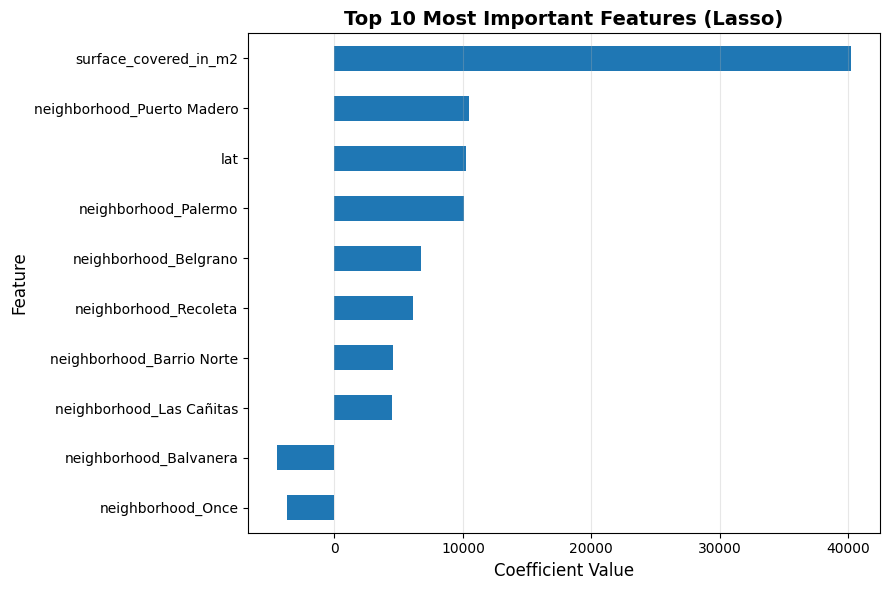

In [ ]:
fig_feat, ax_feat = plt.subplots(figsize=(9, 6))
imp_feat.sort_values(key=abs).tail(10).plot(kind="barh", ax=ax_feat)
ax_feat.set_title("Top 10 Most Important Features (Lasso)", fontsize=14, fontweight='bold')
ax_feat.set_xlabel("Coefficient Value", fontsize=12)
ax_feat.set_ylabel("Feature", fontsize=12)
ax_feat.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
top_feature= imp_feat.idxmax()
top_coef= imp_feat.max()
print(f"The most influential positive feature is: {top_feature}")
print(f"Its coefficient is: ${top_coef:,.2f}")

The most influential positive feature is: surface_covered_in_m2
Its coefficient is: $40,235.36


#**Project Final Conclusion**
### Executive Summary
This project evaluated multiple predictive regression models to estimate real estate prices based on property size, geographical coordinates, and categorical neighborhood indicators. Through rigorous cross-validation and feature selection, linear modeling demonstrated a substantial improvement over baseline estimates while revealing key insights into property valuation drivers and model constraints.

---

### Key Outcomes & Findings

* **Model Performance:** Cross-validated regularized regression models (**LassoCV** and **RidgeCV**) significantly outperformed the baseline, reducing Root Mean Squared Error (RMSE) from **$\$59,227.73$** down to **$\$35,564.49$** ($\approx 40\%$ error reduction).
* **Final Model Selection:** **LassoCV** was selected as the optimal production model. Although RidgeCV achieved a marginally lower test error ($\$35,532.23$), Lasso offered equivalent predictive accuracy while eliminating **2 redundant features**, creating a simpler and more interpretable 57-feature model.
* **Primary Price Drivers:** Covered surface area (`surface_covered_in_m2`) emerged as the single most dominant feature ($\approx \$40,235$ coefficient impact), followed by geographical positioning and premium neighborhood location (e.g., **Puerto Madero**, **Palermo**).
* **Model Limitations & Heteroscedasticity:** Diagnostic analysis revealed a distinct **funnel-shaped residual pattern**. While highly accurate and unbiased for mid-range properties ($\le \$150,000$), the linear model systematically underpredicts values for luxury properties due to unobserved non-linear pricing features.

---

### Strategic Recommendations & Next Steps

1. **Deployment Scope:** Utilize the LassoCV model primarily for standard and mid-tier residential valuations where predictions are most reliable.
2. **Luxury Valuation Handling:** Apply wider confidence intervals or manual appraisal adjustments when estimating high-end real estate ($>\$200,000$).
3. **Future Iterations:** Explore **log-transforming the target variable ($\log(y)$)** or deploying tree-based non-linear algorithms (**Random Forest**, **XGBoost**) to effectively resolve heteroscedasticity and better capture luxury market dynamics.